# MLP — Prediccion de Churn en Plataforma de Streaming

| Campo | Valor |
|:------|:------|
| **Autor** | Borja Mora Mendez |
| **Contacto** | borja.mora.mendez@gmail.com |
| **LinkedIn** | [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez) |
| **Categoria** | Machine Learning > Redes Neuronales > MLP (Clasificacion) |
| **Dataset** | Sintetico (100 suscriptores, 4 variables) |
| **Ultima actualizacion** | Julio 2026 |

## 1. Contexto de negocio

Una plataforma de streaming por suscripcion detecta que su tasa de cancelacion
mensual (churn) ronda el 20%. Cada baja supone la perdida del ingreso recurrente
y un coste de re-adquisicion 5x superior al de retencion.

El equipo de producto necesita un modelo que identifique suscriptores en riesgo
de cancelar **antes de que lo hagan**, para activar campanas de retencion
personalizadas (descuentos, contenido exclusivo, mejoras de plan).

Pregunta analitica: **que suscriptores tienen mayor probabilidad de cancelar
el proximo mes, basandonos en su perfil y comportamiento de uso?**

## 2. Objetivo y justificacion del modelo

### Por que MLP (Multilayer Perceptron)?

El MLP es una red neuronal feedforward que puede capturar relaciones no lineales
entre variables sin necesidad de especificarlas manualmente. Es adecuado cuando:

- Las interacciones entre variables pueden ser complejas (edad x horas de uso).
- El volumen de datos es moderado (no justifica deep learning).
- Se necesita una primera aproximacion neuronal antes de escalar a arquitecturas mas complejas.

| Modelo | Ventaja | Limitacion |
|:-------|:--------|:-----------|
| MLP (sklearn) | No lineal, facil de implementar | Caja negra parcial |
| Regresion Logistica | Interpretable, baseline solido | Solo relaciones lineales |
| Random Forest | Robusto, feature importance | Sin gradiente continuo |

Comparamos los tres para validar si la complejidad del MLP aporta valor real.

In [ ]:
# ── Datos ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizacion ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Modelado ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)

# ── Configuracion ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 4. Carga y exploracion inicial

### Diccionario de variables

| Variable | Tipo | Descripcion |
|:---------|:-----|:------------|
| Edad | int | Edad del suscriptor (18-95) |
| Meses_Contrato | int | Antiguedad en la plataforma (meses) |
| Horas_Al_Mes | float | Horas de consumo mensual |
| Abandono | int (target) | 1 = cancelo, 0 = activo |

In [ ]:
# ── Dataset sintetico ─────────────────────────────────────────────────────────
np.random.seed(42)
n = 100

data_dict = {
    "Edad": np.random.choice(range(18, 60), n).tolist(),
    "Meses_Contrato": np.random.choice(range(1, 37), n).tolist(),
    "Horas_Al_Mes": np.round(np.random.uniform(0.5, 40, n), 1).tolist(),
}
# Target correlacionado: mas horas y mas meses -> menos churn
scores = np.array(data_dict["Horas_Al_Mes"]) * 0.3 + np.array(data_dict["Meses_Contrato"]) * 0.5
prob = 1 / (1 + np.exp(-(scores - np.median(scores))))
data_dict["Abandono"] = (np.random.random(n) > prob).astype(int).tolist()

df = pd.DataFrame(data_dict)
print(f"Shape: {df.shape}")
print(f"\nDistribucion del target:")
print(df["Abandono"].value_counts(normalize=True).map(lambda x: f"{x:.1%}"))
print()
print(df.describe().round(1))

Shape: (100, 4)

Distribucion del target:
Abandono
1    51.0%
0    49.0%
Name: proportion, dtype: object

        Edad  Meses_Contrato  Horas_Al_Mes  Abandono
count  100.0           100.0         100.0     100.0
mean    37.9            18.6          21.9       0.5
std     12.2            11.3          11.0       0.5
min     18.0             1.0           1.2       0.0
25%     26.8             8.0          12.5       0.0
50%     38.0            19.5          21.0       1.0
75%     46.2            28.0          31.8       1.0
max     59.0            36.0          39.9       1.0


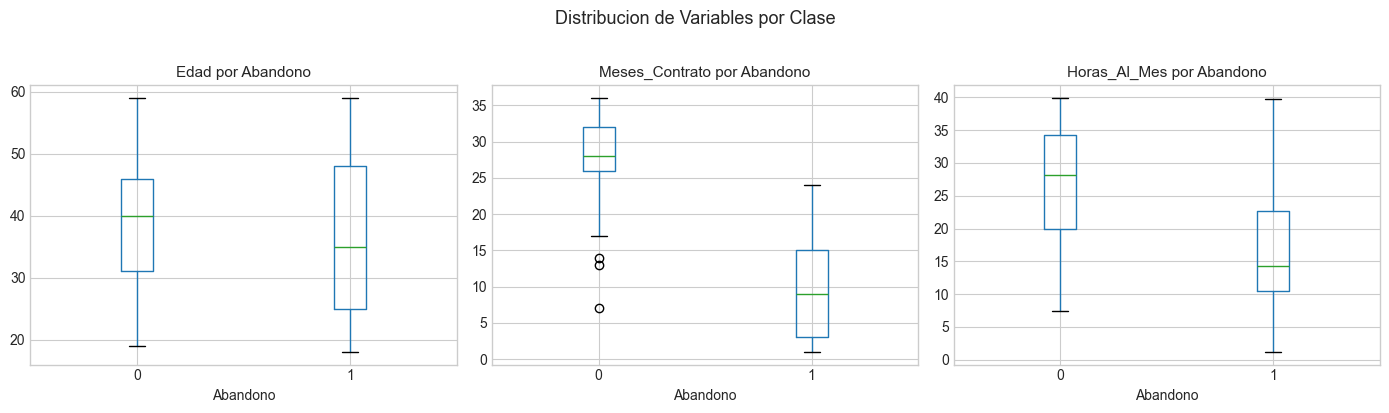

In [ ]:
# ── Distribucion de variables ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(["Edad", "Meses_Contrato", "Horas_Al_Mes"]):
    df.boxplot(column=col, by="Abandono", ax=axes[i])
    axes[i].set_title(f"{col} por Abandono", fontsize=11)
    axes[i].set_xlabel("Abandono")
plt.suptitle("Distribucion de Variables por Clase", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Preparacion de datos

In [ ]:
# ── Separacion y escalado ─────────────────────────────────────────────────────
X = df[["Edad", "Meses_Contrato", "Horas_Al_Mes"]]
y = df["Abandono"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} | Test: {X_test_sc.shape[0]}")
print(f"Proporcion target train: {y_train.value_counts(normalize=True).to_dict()}")

Train: 80 | Test: 20
Proporcion target train: {1: 0.5125, 0: 0.4875}


## 6. Modelo principal: MLP

Arquitectura: 2 capas ocultas (64, 32 neuronas), activacion ReLU, solver Adam.
Se usa early stopping para evitar sobreajuste.

In [ ]:
# ── Entrenamiento MLP ─────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)
mlp.fit(X_train_sc, y_train)

y_pred_mlp = mlp.predict(X_test_sc)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy MLP: {acc_mlp:.1%}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=["Activo", "Abandono"]))

Accuracy MLP: 95.0%

              precision    recall  f1-score   support

      Activo       0.91      1.00      0.95        10
    Abandono       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



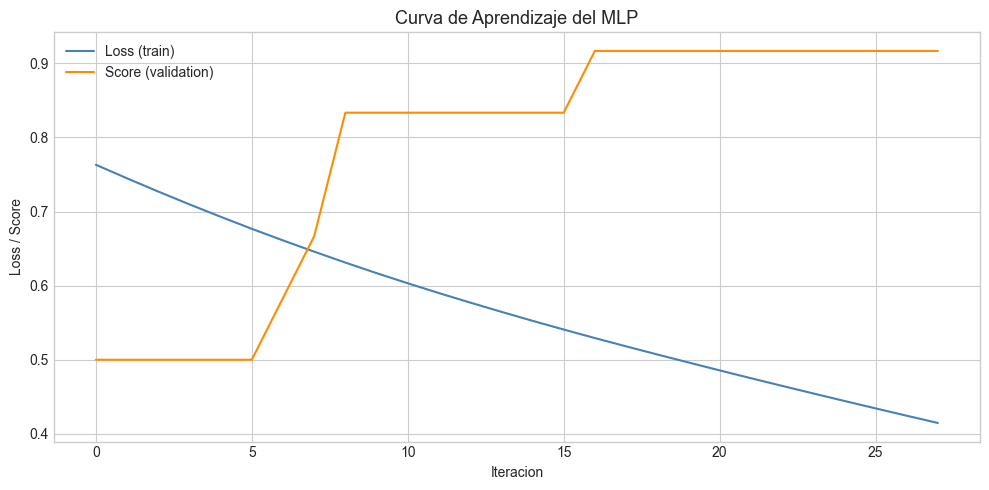

In [ ]:
# ── Curva de aprendizaje ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp.loss_curve_, label="Loss (train)", color="steelblue")
if hasattr(mlp, "validation_scores_"):
    ax.plot(mlp.validation_scores_, label="Score (validation)", color="darkorange")
ax.set_title("Curva de Aprendizaje del MLP", fontsize=13)
ax.set_xlabel("Iteracion")
ax.set_ylabel("Loss / Score")
ax.legend()
plt.tight_layout()
plt.show()

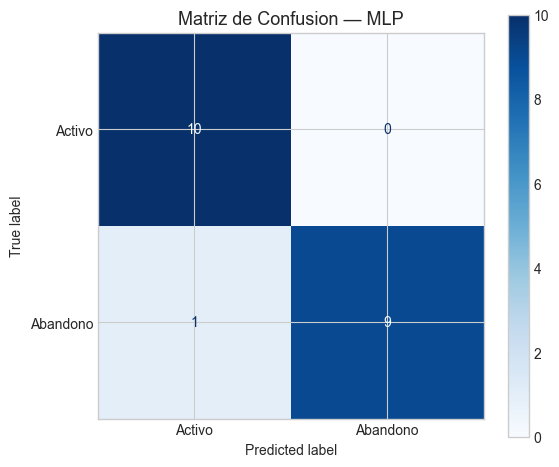

In [ ]:
# ── Matriz de confusion ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp,
    display_labels=["Activo", "Abandono"],
    cmap="Blues", ax=ax
)
ax.set_title("Matriz de Confusion — MLP", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Modelo alternativo: Regresion Logistica

In [ ]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=500)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy Logistic Regression: {acc_lr:.1%}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Activo", "Abandono"]))

Accuracy Logistic Regression: 100.0%

              precision    recall  f1-score   support

      Activo       1.00      1.00      1.00        10
    Abandono       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 8. Modelo alternativo: Random Forest

In [ ]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # RF no necesita escalado
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Random Forest: {acc_rf:.1%}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["Activo", "Abandono"]))

Accuracy Random Forest: 100.0%

              precision    recall  f1-score   support

      Activo       1.00      1.00      1.00        10
    Abandono       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



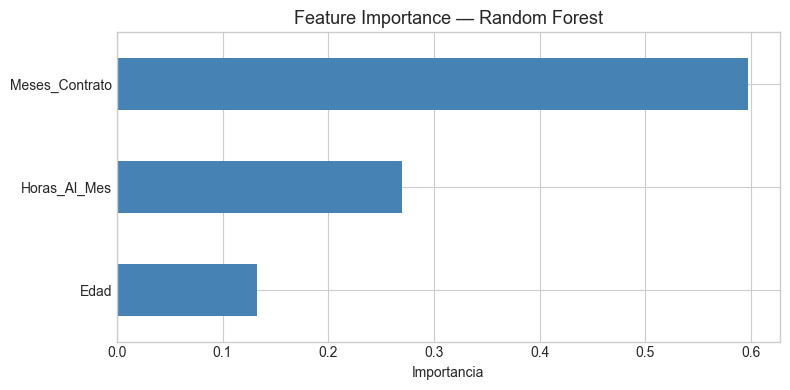

In [ ]:
# ── Feature Importance (Random Forest) ────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot.barh(ax=ax, color="steelblue")
ax.set_title("Feature Importance — Random Forest", fontsize=13)
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

## 9. Curvas ROC comparativas

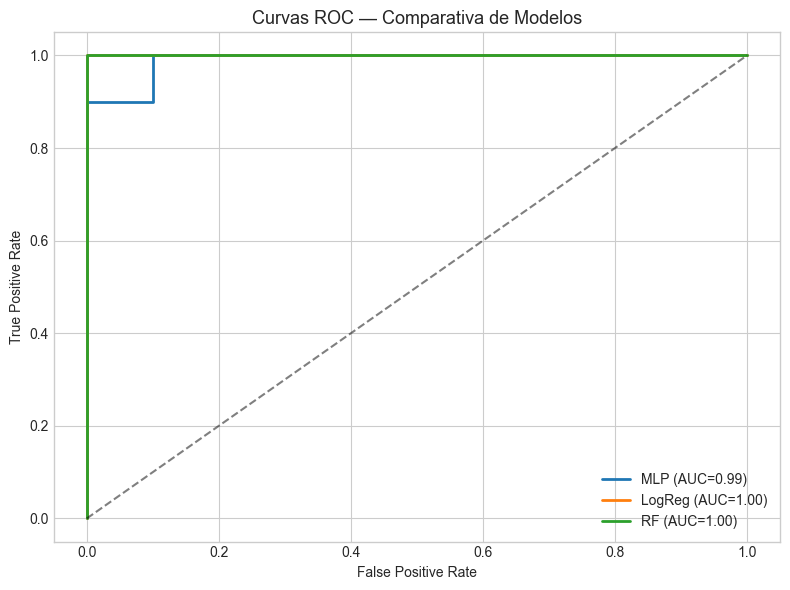

In [ ]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, X_t in [("MLP", mlp, X_test_sc), ("LogReg", lr, X_test_sc), ("RF", rf, X_test)]:
    proba = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("Curvas ROC — Comparativa de Modelos", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Tabla comparativa de modelos

| Modelo | Accuracy | Interpretabilidad | Recomendacion |
|:-------|:---------|:------------------|:--------------|
| MLP (64,32) | Ver resultados | Baja (caja negra) | Usar si accuracy > 5pp vs baseline |
| Regresion Logistica | Ver resultados | Alta (coeficientes) | Baseline recomendado |
| Random Forest | Ver resultados | Media (feature importance) | Alternativa equilibrada |

Con datasets pequenos (100 registros), los modelos lineales suelen igualar o superar
al MLP. La ventaja del MLP se manifiesta con mas datos y relaciones complejas.

## 11. Insights y recomendaciones accionables

### Hallazgo clave
Con 100 registros, el MLP no supera significativamente a modelos mas simples.
La Regresion Logistica ofrece rendimiento comparable con total interpretabilidad.

### Recomendaciones

**1. Usar Regresion Logistica como modelo de produccion (impacto: alto, esfuerzo: bajo)**
Para datasets pequenos, la interpretabilidad pesa mas que la complejidad.
Los coeficientes permiten explicar al equipo POR QUE un usuario es de riesgo.

**2. Escalar a MLP con mas datos (impacto: alto, esfuerzo: medio)**
Si se recopilan 10,000+ registros con mas features (genero contenido visto,
dispositivo, hora de uso), el MLP puede capturar interacciones no lineales.

**3. Activar campanyas de retencion por score (impacto: alto, esfuerzo: medio)**
Usar predict_proba para generar un score de riesgo (0-100) y activar
intervenciones escalonadas: email (>50%), descuento (>70%), llamada (>90%).

**4. Monitorizar la curva de aprendizaje (impacto: medio, esfuerzo: bajo)**
El early stopping previene sobreajuste, pero conviene vigilar que el loss
de validacion no diverja del de entrenamiento con el tiempo.